In [1]:
# ==============================================================================
# STEP 1: ENVIRONMENT SETUP
# ==============================================================================
# To ensure "one-click" reproducibility, I clone a curated repository containing the streamlined GeoJSON data and PCA factors.
!git clone https://github.com/aanugrah/AIGov-Asg1a

# Change the working directory to the project folder to access local files
%cd AIGov-Asg1a

Cloning into 'AIGov-Asg1a'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 2.89 MiB | 5.08 MiB/s, done.
/content/AIGov-Asg1a


In [2]:
# ==============================================================================
# STEP 2: LIBRARIES AND GLOBAL CONFIGURATION
# ==============================================================================

# Core data manipulation and numerical operations
import numpy as np
import pandas as pd

# Geospatial data handling for the LSOA GeoJSON dataset
import geopandas as gpd

# Machine Learning: ensemble methods and cross-validation tools
import sklearn as skl
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import sklearn.model_selection as cv
from sklearn.metrics import r2_score

# Visualization: Matplotlib and Seaborn for high-fidelity density plots
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook configuration for inline plotting and consistent visual styling
%matplotlib inline
sns.set(style="whitegrid")

In [3]:
# ==============================================================================
# STEP 3: DATA LOADING AND FEATURE SELECTION
# ==============================================================================
# ADAPTATION NOTE: The original file paths are updated to reference the curated root directory, eliminating dependency on external local folders.

# The primary spatial dataset containing urban features for Liverpool is loaded.
db = gpd.read_file('satellite_features_lsoa_liv.geojson').set_index('LSOA11CD')
factors_jc = pd.read_csv('Variables_PCF.csv', index_col=0)[['f1', 'f2', 'f3', 'f4']]

# Specific land-use features are defined according to the original methodology.
lu = ['p_veg', 'p_b_water', 'p_shadow']
lu_all = [i for i in db.columns if i[:2]=='p_'] + ['f_or_imp_s']
fetex = [i for i in db.columns if (i[0]==i[0].upper()) and (i!='IDfetex')]

In [4]:
# ==============================================================================
# STEP 4: MODEL EVALUATION AND PERFORMANCE COMPARISON
# ==============================================================================

%%time

# A global seed is established to ensure the reproducibility of results.
np.random.seed(1234)

# Predictor sets are finalized for both linear (OLS) and non-linear (RF/GBR) models.
xy = db[lu_all].join(factors_jc)
x_all = db[lu_all + fetex]

# Models are initialized using the parameters specified in the original paper.
ols = skl.linear_model.LinearRegression()
rf = RandomForestRegressor(n_estimators=100)

# ADAPTATION NOTE: The Gradient Boosting loss parameter is updated from 'lad'
# to 'absolute_error' to maintain compatibility with scikit-learn v1.2+.
gbr = GradientBoostingRegressor(n_estimators=100, \
                                max_depth=4, \
                                min_samples_split=2, \
                                learning_rate=0.035, \
                                loss='absolute_error')

# A cross-validation loop of 250 iterations is executed to generate a distribution of performance metrics (R-squared).
scores = []
for i in range(250):
    # The dataset is partitioned using a 60/40 train-test split ratio.
    # The random_state is incremented in each loop to ensure a unique split.
    x_train, x_test, y_train, y_test = cv.train_test_split(x_all, db['living_env'], \
                test_size=0.4, random_state=i)

    # Random Forest (RF) model is trained and evaluated using all urban features.
    rfer_all = rf.fit(x_train, y_train)
    rf_all_predy = rfer_all.predict(x_test)
    rf_all_r2 = skl.metrics.r2_score(y_test, rf_all_predy)

    # Gradient Boosting (GBR) model is trained and evaluated using all urban features.
    gbr_all = gbr.fit(x_train, y_train)
    gbr_all_predy = gbr_all.predict(x_test)
    gbr_all_r2 = skl.metrics.r2_score(y_test, gbr_all_predy)

    # Data is re-split using the OLS-specific feature set (Land-use + PCA Factors).
    x_train, x_test, y_train, y_test = cv.train_test_split(xy, db['living_env'], \
                test_size=0.4, random_state=i)

    # Ordinary Least Squares (OLS) baseline is trained and evaluated.
    olser = ols.fit(x_train, y_train)
    ols_predy = olser.predict(x_test)
    ols_r2 = skl.metrics.r2_score(y_test, ols_predy)

    # Performance metrics for each iteration are appended to the results list.
    scores.append((ols_r2, rf_all_r2, gbr_all_r2))

# Results are compiled into a pandas DataFrame for statistical analysis and visualization.
scores = pd.DataFrame(np.array(scores), columns=['OLS', 'RF', 'GBR'])


CPU times: user 3min 40s, sys: 345 ms, total: 3min 40s
Wall time: 3min 48s


Median values
RF     0.536998
GBR    0.496933
OLS    0.317247
dtype: float64


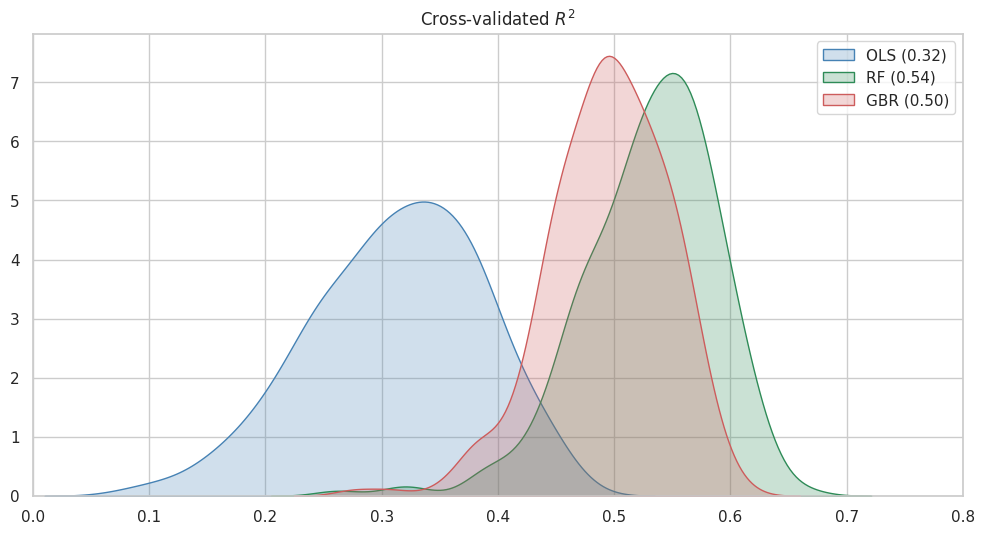

In [11]:
# ==============================================================================
# STEP 5: VISUALIZATION AND RESULTS REPORTING
# ==============================================================================
# The median R-squared values are calculated and displayed to confirm that the replication matches the original study's benchmarks.
print('Median values')
print(scores.median().sort_values(ascending=False))

# ADAPTATION NOTE: A specific color palette is defined to ensure the visual output strictly matches the aesthetics of the original paper (Fig 4).
colors = {'OLS': 'steelblue', 'RF': 'seagreen', 'GBR': 'indianred'}

# A figure is initialized to host the density-based performance distribution.
f, ax = plt.subplots(1, figsize=(12, 6))

# ADAPTATION NOTE: The plotting loop is refactored to ensure a consistent legend order. The 'shade' parameter from the 2017 codebase is updated to 'fill' to maintain compatibility with newer Seaborn.
for col in ['OLS', 'RF', 'GBR']:
    med = scores[col].median()
    sns.kdeplot(scores[col],
                ax=ax,
                fill=True,
                color=colors[col],
                label="%s (%.2f)" % (col, med))

# The chart is finalized with technical labels and axis constraints to replicate the exact scale (0.0 to 0.8) used in the original analysis.
plt.title('Cross-validated $R^2$')
plt.xlabel(None)
plt.xlim(0, 0.8)
plt.ylabel(None)
plt.legend()
plt.show()